In [1]:
# change working directory to '..'
import os
os.chdir('/mnt/CalebDrive/cmorton/Challenge 2.1/DLS_Transformer/')

import numpy as np
import matplotlib.pyplot as plt
import h5py

from pathlib import Path
import importlib
import importlib.util
import warnings

from lib import dls
if importlib.util.find_spec("torch") is None or importlib.util.find_spec("torch.nn") is None:
    warnings.warn(
        "PyTorch is not available in this environment. "
        "Install it with: pip install torch",
        ImportWarning,
        stacklevel=2,
    )
else:
    from lib import models
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

Using device: cpu


/mnt/CalebDrive/cmorton/Challenge 2.1/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
importlib.reload(dls)
# importlib.reload(models)

<module 'lib.dls' from '/mnt/CalebDrive/cmorton/Challenge 2.1/DLS_Transformer/lib/dls.py'>

In [3]:
# Choose decomposition method: "dls" or "pod"
decomp_method = "dls"
# Choose dataset: "ldc" or "piv"
data_name = "piv"

In [4]:
# Paths
if "__file__" in globals():
    script_dir = Path(__file__).parent.resolve()
else:
    script_dir = Path.cwd()
data_dir = script_dir / '..' / 'data'
fig_dir = script_dir / 'figures'

# Hindcast/forecast lengths
nt_hind = 70
nt_fore = 30
nt_episode = nt_hind + nt_fore

# DLS parameters
patch_size = 11
n_modes = 10

# Load data
if data_name == "piv":
    with h5py.File(data_dir / "Challenge2_1_train.h5", 'r') as f:
        ux_train = np.array(f['/ux'])
        uy_train = np.array(f['/uy'])
        print(f"Loaded training data: ux_train shape {ux_train.shape}, uy_train shape {uy_train.shape}")

    with h5py.File(data_dir / "Challenge2_1_test_input.h5", 'r') as f:
        ux_test_input = np.array(f['/ux'])
        uy_test_input = np.array(f['/uy'])
        print(f"Loaded test input data: ux_test_input shape {ux_test_input.shape}, uy_test_input shape {uy_test_input.shape}")

    with h5py.File(data_dir / "Challenge2_1_grid.h5", 'r') as f:
        x = np.array(f['/x'])[::-1]  # reverse order to match velocity field orientation
        y = np.array(f['/y'])
        print(f"Loaded grid data: x shape {x.shape}, y shape {y.shape}")
        
        # grid uniformity check
        dx = np.diff(x[:, 0])
        dy = np.diff(y[:, 0])
        print(f"Grid uniformity check: dx mean {dx.mean():.6f}, dx std {dx.std():.6f}, dy mean {dy.mean():.6f}, dy std {dy.std():.6f}")

    with h5py.File(data_dir / 'Challenge2_1_parameters.h5', 'r') as f:
        dt = np.asarray(f["dt"]).squeeze().item()
        print(f"Loaded parameters: dt = {dt}")

if data_name == "ldc":
    with h5py.File(data_dir / "ldc_15k.h5", 'r') as f:
        u = np.array(f['/UV'])
        print(f"Loaded training data: u_train shape {u.shape}")

Loaded training data: ux_train shape (12800, 154, 51), uy_train shape (12800, 154, 51)
Loaded test input data: ux_test_input shape (32, 70, 154, 51), uy_test_input shape (32, 70, 154, 51)
Loaded grid data: x shape (154, 1), y shape (51, 1)
Grid uniformity check: dx mean 0.037411, dx std 0.000000, dy mean 0.037411, dy std 0.000000
Loaded parameters: dt = 6.25e-05


In [5]:
if data_name == "ldc":
    ux_train = u[:2000,:154,:51,0]
    uy_train = u[:2000,:154,:51,1]
    ux_test = u[2000:,:154,:51,0]
    uy_test = u[2000:,:154,:51,1]

    # split test input into 30 samples of 70 time steps each
    ux_test_input = np.zeros((30, nt_hind, ux_test.shape[1], ux_test.shape[2]))
    uy_test_input = np.zeros((30, nt_hind, uy_test.shape[1], uy_test.shape[2]))
    for i in range(30):
        start_idx = i
        end_idx = start_idx + nt_hind
        # print(f"Preparing test sample {i}: start_idx={start_idx}, end_idx={end_idx}")
        ux_test_input[i] = ux_test[start_idx:end_idx]
        uy_test_input[i] = uy_test[start_idx:end_idx]

    x = np.linspace(0, 1, ux_train.shape[1])[:154]
    y = np.linspace(0, 1, ux_train.shape[2])[:51]
    print(f"Loaded training data: ux_train shape {ux_train.shape}, uy_train shape {uy_train.shape}")


# Dimensions and 2D grid
nt_train, nx, ny = ux_train.shape
yy, xx = np.meshgrid(y, x)

n_sample_train = nt_train // nt_episode
if n_sample_train < 1:
    raise ValueError(f"Not enough training data: nt_train={nt_train} is less than nt_episode={nt_episode}")


n_train_used = n_sample_train * nt_episode
n_sample_test = ux_test_input.shape[0]
ux_forecast = np.zeros((n_sample_test, nt_fore, nx, ny ))
uy_forecast = np.zeros((n_sample_test, nt_fore, nx, ny ))

nt_test = n_sample_test * nt_episode
n_layer = 128
n_epoch = 200
n_miniBatch = 26
n_patience = 200

ux_mean = np.mean(ux_train, axis=0, keepdims=True)
uy_mean = np.mean(uy_train, axis=0, keepdims=True)
ux_train = ux_train - ux_mean
uy_train = uy_train - uy_mean
ux_test_input = ux_test_input - ux_mean
uy_test_input = uy_test_input - uy_mean

Q_train = np.concatenate((ux_train[...,np.newaxis], uy_train[...,np.newaxis]), axis=3)
Q_test_input = np.concatenate((ux_test_input[...,np.newaxis], uy_test_input[...,np.newaxis]), axis=4)

print(f"Prepared data shapes: Q_train shape={Q_train.shape}, Q_test_input shape={Q_test_input.shape}")

Prepared data shapes: Q_train shape=(12800, 154, 51, 2), Q_test_input shape=(32, 70, 154, 51, 2)


In [6]:
if decomp_method.lower() == "dls":
    importlib.reload(dls)
    dof_u_train, dof_v_train, dls_config = dls.dls_Decomp_2D(Q_train, xx, yy, patch_size, n_modes)

    dof_u_test_input, dof_v_test_input, _ = dls.dls_Decomp_2D(
        Q_test_input, xx, yy, patch_size, n_modes,
        modemat_u=dls_config['modemat_local_u'],
        modemat_v=dls_config['modemat_local_v']
    )

    print(
        f"Decomposed training data (DLS): dof_u.shape={dof_u_train.shape}, dof_v.shape={dof_v_train.shape}\n"
        f"modemat_local_u.shape={dls_config['modemat_local_u'].shape}, "
        f"modemat_local_v.shape={dls_config['modemat_local_v'].shape}"
    )
    print(f"Decomposed test data (DLS): dof_u.shape={dof_u_test_input.shape}, dof_v.shape={dof_v_test_input.shape}")

    # Stack dof_u and dof_v along the dof dimension for forecasting
    dof_train = np.concatenate((dof_u_train, dof_v_train), axis=-1)
    dof_test_input = np.concatenate((dof_u_test_input, dof_v_test_input), axis=-1)
    print(f"Combined DOF shapes: dof_train shape={dof_train.shape}")
    print(f"Combined test input DOF shape: dof_test_input shape={dof_test_input.shape}")

Data shape: (154, 51), patch_size: 11, num_patches: 10000
Data shape: (154, 51), patch_size: 11, num_patches: 10000
Constructing global M GFEM matrix
Done prefactorizing M
Constructing global M GFEM matrix
Done prefactorizing M
Decomposed training data (DLS): dof_u.shape=(12800, 3751), dof_v.shape=(12800, 3751)
modemat_local_u.shape=(36, 44), modemat_local_v.shape=(36, 44)
Decomposed test data (DLS): dof_u.shape=(32, 70, 3751), dof_v.shape=(32, 70, 3751)
Combined DOF shapes: dof_train shape=(12800, 7502)
Combined test input DOF shape: dof_test_input shape=(32, 70, 7502)


In [7]:
if decomp_method.lower() == "dls":
    importlib.reload(dls)
    dls.vis_modes(dls_config, save_dir=fig_dir / 'dls_modes.png')

In [8]:
# if decomp_method.lower() == "dls":
#     importlib.reload(dls)
#     dof_u_train, dof_v_train, dls_config = dls.gfem_2d(Q_train[:1], patch_size, n_modes)

Reconstructed training data shape: Q_train_recon shape=(2, 1, 151, 51)
xg_shape=(151, 51), yg_shape=(151, 51), q_orig_shape=(151, 51), q_rec_shape=(151, 51)


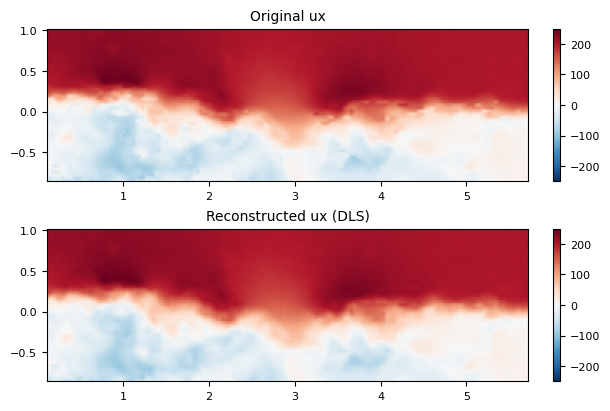

In [9]:
# sanity check: reconstruct the fields from the DOFs and compare to original
if decomp_method.lower() == "dls":
    importlib.reload(dls)
    Q_train_rec_snap = dls.dls_Rec_2D(dof_u_train[:1].T, dof_v_train[:1].T, dls_config)

    nx_t, ny_t = dls_config['nx_t'], dls_config['ny_t']
    print(f"Reconstructed training data shape: Q_train_recon shape={Q_train_rec_snap.shape}")

    # plot comparison on physical grid
    xg = xx[:nx_t, :ny_t]
    yg = yy[:nx_t, :ny_t]
    q_orig = Q_train[0, :nx_t, :ny_t, 0] + ux_mean[0, :nx_t, :ny_t]
    q_rec = Q_train_rec_snap[0, 0, :nx_t, :ny_t] + ux_mean[0, :nx_t, :ny_t]

    vabs = max(np.max(np.abs(q_orig)), np.max(np.abs(q_rec)))
    
    print(f"xg_shape={xg.shape}, yg_shape={yg.shape}, q_orig_shape={q_orig.shape}, q_rec_shape={q_rec.shape}")

    plt.figure(figsize=(6, 4))
    plt.subplot(2, 1, 1)
    plt.title("Original ux")
    plt.pcolormesh(xg, yg, q_orig, shading='gouraud', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
    plt.colorbar()

    plt.subplot(2, 1, 2)
    plt.title("Reconstructed ux (DLS)")
    plt.pcolormesh(xg, yg, q_rec, shading='gouraud', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
    plt.colorbar()
    plt.savefig(fig_dir / 'dls_reconstruction.png', dpi=300)

In [10]:
# # sanity check: reconstruct the fields from the DOFs and compare to original
# if decomp_method.lower() == "dls":
#     importlib.reload(dls)
#     Q_train_rec_snap = dls.gfem_recon(dof_u_train.T, dof_v_train.T, dls_config)

#     nx_t, ny_t = dls_config.nx_t, dls_config.ny_t
#     print(f"Reconstructed training data shape: Q_train_recon shape={Q_train_rec_snap.shape}")

#     # plot comparison on physical grid
#     xg = xx[:nx_t, :ny_t]
#     yg = yy[:nx_t, :ny_t]
#     q_orig = Q_train[0, :nx_t, :ny_t, 0]
#     q_rec = Q_train_rec_snap[:nx_t, :ny_t, 0, 0]

#     vabs = max(np.max(np.abs(q_orig)), np.max(np.abs(q_rec)))

#     plt.figure()
#     plt.subplot(2, 1, 1)
#     plt.title("Original ux")
#     plt.pcolormesh(xg, yg, q_orig, shading='auto', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
#     plt.colorbar()

#     plt.subplot(2, 1, 2)
#     plt.title("Reconstructed ux (DLS)")
#     plt.pcolormesh(xg, yg, q_rec, shading='auto', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
#     plt.colorbar()

#     plt.tight_layout()
#     plt.show()

In [11]:
if decomp_method.lower() == "pod":
    Q_train = Q_train.reshape(nt_train, -1)

    Q_mean = np.mean(Q_train, axis=0)
    Q_center = Q_train - Q_mean


In [12]:
if decomp_method.lower() == "pod":
    # SVD-based POD
    print("Performing SVD for POD decomposition...")
    phi, sigma, V = np.linalg.svd(Q_center[:2000].T, full_matrices=False)
    print(f"SVD completed: phi shape={phi.shape}")
    r = min(n_modes, phi.shape[0])

    


In [13]:
if decomp_method.lower() == "pod":
    print(f"Q_center shape={Q_center.shape}, phi shape={phi.shape}, r={r}")
    V = V[:, :r]
    phi = phi[:,:r]  # (nx*ny, r_u)
    smat = np.diag(sigma)  # (r, r)
    dof_train = Q_center @ phi  # (nt_train, r)

In [14]:
if decomp_method.lower() == "pod":
    # Project test input with same POD modes
    # Q_test_input expected shape (n_sample_test, nt_hind, nx, ny, 2)
    n_sample_test, nt_hind, nx, ny, n_comp = Q_test_input.shape
    print(f"Reshaping test input for projection: original shape={Q_test_input.shape}, reshaped to (n_sample_test, nt_hind, nx*ny*2)")
    Q_test_input_reshaped = Q_test_input.reshape(n_sample_test, nt_hind, -1)  # (n_sample_test, nt_hind, nx*ny*2)
    dof_test_input = np.zeros((n_sample_test, nt_hind, r))
    print(f"Projecting test input onto POD modes: Q_test_input_reshaped shape={Q_test_input_reshaped.shape}, phi shape={phi.shape}, r={r}")
    for i in range(n_sample_test):
        dof_test_input[i] = Q_test_input_reshaped[i] @ phi  # (nt_hind, r)
    print(f"Decomposed training data (POD): dof_train shape={dof_train.shape}, phi shape={phi.shape}")
    print(f"Decomposed test data (POD): dof_test_input shape={dof_test_input.shape}")

In [15]:
# Sanity check: reconstruct a sample from the training data using the POD modes
if decomp_method.lower() == "pod":
    sample_idx = 0
    dof_sample = dof_train[sample_idx]  # (r,)
    Q_reconstructed = dof_sample @ phi.T + Q_mean  # (nx*ny*2,)
    Q_reconstructed_reshaped = Q_reconstructed.reshape(nx, ny, 2)  # (nx, ny, 2)
    print(f"Reconstructed sample shape: {Q_reconstructed_reshaped.shape}")
    # Plot original vs reconstructed for the first component (ux)
    Q_original = Q_train[sample_idx].reshape(nx, ny, 2)
    plt.figure()
    plt.subplot(2,1, 1)
    plt.title("Original ux")
    plt.pcolormesh(xx, yy, Q_original[..., 0], shading='auto', cmap='RdBu_r')
    plt.colorbar()
    plt.subplot(2,1, 2)
    plt.title("Reconstructed ux (POD)")
    plt.pcolormesh(xx, yy, Q_reconstructed_reshaped[..., 0], shading='auto', cmap='RdBu_r')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [16]:
####################
## Training Setup ##
####################

A_hind_train = np.zeros((n_sample_train, nt_hind, dof_train.shape[1]))
for i in range(n_sample_train):
    offset = i * nt_episode
    t_idx = range(offset, offset + nt_hind)
    A_hind_train[i] = dof_train[t_idx]

print(f"Prepared hindcast training data: A_hind_train shape={A_hind_train.shape}")

A_hind_test_input = dof_test_input

print(f"Prepared hindcast test input data: A_hind_test_input shape={A_hind_test_input.shape}")

A_mu = np.mean(A_hind_train, axis=(0,1))
A_std = np.std(A_hind_train, axis=(0,1))

A1 = np.zeros((n_sample_train, nt_hind-1, dof_train.shape[1]))
A2 = np.zeros((n_sample_train, nt_hind-1, dof_train.shape[1]))
for i in range(n_sample_train):
    A_this = (A_hind_train[i] - A_mu[np.newaxis, :]) / A_std[np.newaxis, :]
    A1[i] = A_this[:-1]
    A2[i] = A_this[1:]

A1_test = np.zeros((n_sample_test, nt_hind-1, dof_test_input.shape[-1]))
A2_test = np.zeros((n_sample_test, nt_hind-1, dof_test_input.shape[-1]))
for i in range(n_sample_test):
    A_this = (A_hind_test_input[i] - A_mu[np.newaxis, :]) / A_std[np.newaxis, :]
    A1_test[i] = A_this[:-1]
    A2_test[i] = A_this[1:]

print(f"Prepared training data: A1 shape={A1.shape}, A2 shape={A2.shape}")
print(f"Prepared test data: A1_test shape={A1_test.shape}, A2_test shape={A2_test.shape}")

Prepared hindcast training data: A_hind_train shape=(128, 70, 7502)
Prepared hindcast test input data: A_hind_test_input shape=(32, 70, 7502)
Prepared training data: A1 shape=(128, 69, 7502), A2 shape=(128, 69, 7502)
Prepared test data: A1_test shape=(32, 69, 7502), A2_test shape=(32, 69, 7502)


Epoch [1/200], Train Loss: 1.1669, Test Loss: 1.0429
Epoch [2/200], Train Loss: 1.0335, Test Loss: 1.0141
Best model saved at epoch 2 with test loss: 1.0141
Epoch [3/200], Train Loss: 1.0142, Test Loss: 1.0080
Best model saved at epoch 3 with test loss: 1.0080
Epoch [4/200], Train Loss: 1.0078, Test Loss: 1.0035
Best model saved at epoch 4 with test loss: 1.0035
Epoch [5/200], Train Loss: 1.0046, Test Loss: 1.0013
Best model saved at epoch 5 with test loss: 1.0013
Epoch [6/200], Train Loss: 1.0018, Test Loss: 0.9999
Best model saved at epoch 6 with test loss: 0.9999
Epoch [7/200], Train Loss: 1.0015, Test Loss: 0.9991
Best model saved at epoch 7 with test loss: 0.9991
Epoch [8/200], Train Loss: 1.0012, Test Loss: 0.9988
Best model saved at epoch 8 with test loss: 0.9988
Epoch [9/200], Train Loss: 0.9996, Test Loss: 0.9998
Epoch [10/200], Train Loss: 0.9980, Test Loss: 0.9998
Epoch [11/200], Train Loss: 0.9976, Test Loss: 0.9998
Epoch [12/200], Train Loss: 0.9971, Test Loss: 1.0006
Epoc

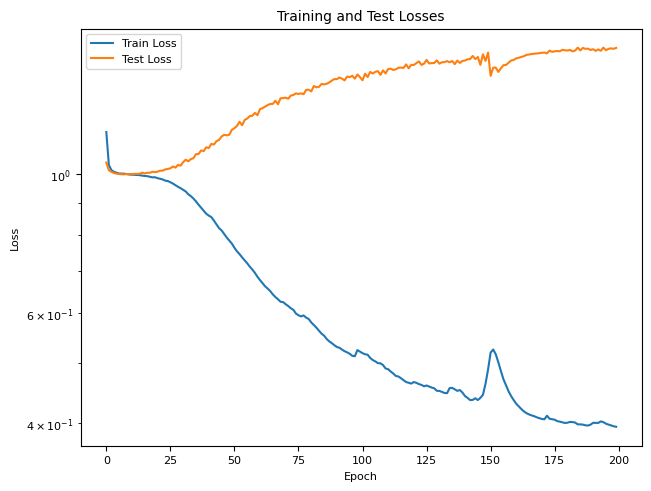

In [17]:
importlib.reload(models)
# model = models.LSTMModel(time_lag=nt_hind-1, input_dim=dof_train.shape[-1], hidden_dim=2048, num_layers=2, dropout=0.0).to(device)
model = models.TransformerEncoderModel(time_lag=nt_hind-1, input_dim=dof_train.shape[-1], d_model=512, nhead=4, num_layers=2, dropout=0.0).to(device)
# print(f"Initialized model: {model}")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loader = models.make_dataloader(torch.tensor(A1, dtype=torch.float32), torch.tensor(A2, dtype=torch.float32), batch_size=n_miniBatch, shuffle=True)
test_loader = models.make_dataloader(torch.tensor(A1_test, dtype=torch.float32), torch.tensor(A2_test, dtype=torch.float32), batch_size=n_miniBatch, shuffle=False)

losses = models.train_model(model, 
                            train_loader, test_loader, 
                            criterion, optimizer, 
                            num_epochs=n_epoch, 
                            patience=n_patience, 
                            device=device, 
                            model_dir=script_dir / 'models', 
                            data_name='challenge2_1', 
                            checkpointing=False)

# plot losses
plt.figure()
plt.plot(losses['train_losses'], label='Train Loss')
plt.plot(losses['test_losses'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.title('Training and Test Losses')
plt.show()

Training NMSE (mean +/- std over all blocks/horizons): 2.818e+00 +/- 1.770e+00


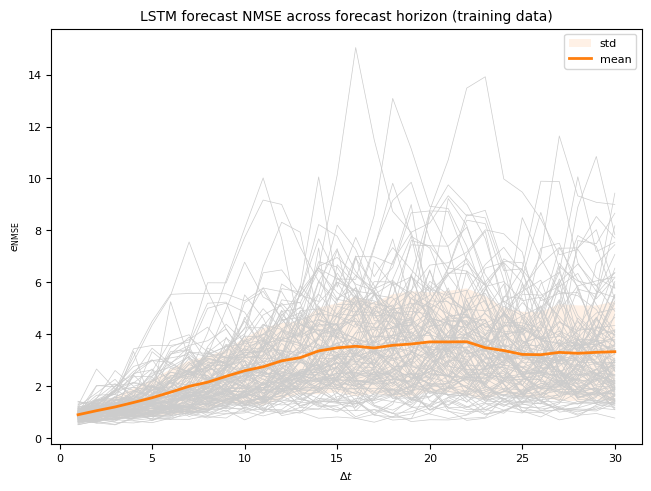

In [27]:
####################################
# Training forecast error analysis #
####################################

importlib.reload(dls)
importlib.reload(models)

A_fore_train = np.zeros((n_sample_train, nt_fore, dof_train.shape[1]))
e_nmse_train = np.zeros((n_sample_train, nt_fore))
f_error_train = plt.figure()

for n in range(n_sample_train):
    idx_start = n * nt_episode
    idx_fore = range(idx_start + nt_hind, idx_start + nt_hind + nt_fore)
    
    Q_fore_true = Q_train[idx_fore].reshape(nt_fore, nx, ny, 2)

    A_in = (A_hind_train[n] - A_mu[np.newaxis, :]) / A_std[np.newaxis, :]
    A_fore = models.forecastClosedLoop(model, A_in, nt_fore, device=device)
    A_fore = A_fore.detach().cpu().numpy()
    A_fore = A_fore * A_std[np.newaxis, :] + A_mu[np.newaxis, :]
    A_fore_train[n] = A_fore

    A_fore = A_fore.squeeze()  # (nt_fore, dof)

    if decomp_method.lower() == "dls":
        num_dofs = dls_config['num_gfem_nodes'] * dls_config['dof_node']
        dof_u_fore = A_fore[:, :num_dofs].T
        dof_v_fore = A_fore[:, num_dofs:].T
        u_rec, v_rec = dls.dls_Rec_2D(dof_u_fore, dof_v_fore, dls_config)
        Q_rec = np.stack((u_rec, v_rec), axis=3)  # (nt_fore, nx, ny, 2)

        for ti in range(nt_fore):
            nx_t, ny_t = dls_config['nx_t'], dls_config['ny_t']
            q_true = Q_fore_true[ti, :nx_t, :ny_t, :]
            q_hat = Q_rec[ti]
            denom = np.mean(q_true**2)
            e_nmse_train[n, ti] = np.mean((q_true - q_hat)**2) / denom if denom != 0 else 0
            

    elif decomp_method.lower() == "pod":
        Q_rec = A_fore @ phi.T  # (nt_fore, nx*ny*2)
        Q_rec = Q_rec.reshape(nt_fore, nx, ny, 2)

        for ti in range(nt_fore):
            q_true = Q_fore_true[ti]
            q_hat = Q_rec[ti]
            denom = np.mean(q_true**2)
            e_nmse_train[n, ti] = np.mean((q_true - q_hat)**2) / denom if denom != 0 else 0

t_fore = np.arange(1, nt_fore + 1)

# Plot each sample's NMSE trajectory in light gray
plt.plot(t_fore, e_nmse_train.T, linewidth=0.5, color=(0.8, 0.8, 0.8))

# Mean and standard deviation across samples at each forecast step
e_nmse_mean = np.mean(e_nmse_train, axis=0)
e_nmse_std = np.std(e_nmse_train, axis=0)


rgb = plt.get_cmap("tab10").colors
h_band = plt.fill_between(
    t_fore,
    e_nmse_mean - e_nmse_std,
    e_nmse_mean + e_nmse_std,
    color=rgb[1],
    alpha=0.1,
    edgecolor="none",
    label="std",
)
h_mean, = plt.plot(t_fore, e_nmse_mean, "-", linewidth=2, color=rgb[1], label="mean")

plt.xlabel(r"$\Delta t$")
plt.ylabel(r"$e_\mathrm{NMSE}$")
plt.title("LSTM forecast NMSE across forecast horizon (training data)")
plt.legend(handles=[h_band, h_mean], loc="best")
plt.savefig(fig_dir / 'train_forecast_nmse.png', dpi=300)

train_nmse_mean = np.mean(e_nmse_train)
train_nmse_std = np.std(e_nmse_train)
print(
    f"Training NMSE (mean +/- std over all blocks/horizons): "
    f"{train_nmse_mean:.3e} +/- {train_nmse_std:.3e}"
)

In [28]:
######################################
# POD-LSTM closed-loop forecast test #
######################################
# forecast test episodes
if decomp_method.lower() == "dls":
    nx_t, ny_t = dls_config['nx_t'], dls_config['ny_t']
elif decomp_method.lower() == "pod":
    nx_t, ny_t = nx, ny
A_fore_test = np.zeros((n_sample_test, nt_fore, dof_test_input.shape[-1]))
ux_forecast = np.zeros((n_sample_test, nt_fore, nx_t, ny_t))
uy_forecast = np.zeros((n_sample_test, nt_fore, nx_t, ny_t))
for n in range(n_sample_test):
    A_in = (A_hind_test_input[n] - A_mu[np.newaxis, :]) / A_std[np.newaxis, :]
    A_fore = models.forecastClosedLoop(model, A_in, nt_fore, device=device)
    A_fore = A_fore.detach().cpu().numpy().squeeze()  # (nt_fore, dof)
    A_fore = A_fore * A_std[np.newaxis, :] + A_mu[np.newaxis, :]
    A_fore_test[n] = A_fore


    if decomp_method.lower() == "dls":
        num_dofs = dls_config['num_gfem_nodes'] * dls_config['dof_node']
        dof_u_fore = A_fore[:, :num_dofs].T
        dof_v_fore = A_fore[:, num_dofs:].T
        u_rec, v_rec = dls.dls_Rec_2D(dof_u_fore, dof_v_fore, dls_config)
        Q_rec = np.stack((u_rec, v_rec), axis=3)  # (nt_fore, nx, ny, 2)
        
        ux_forecast[n] = Q_rec[:, :nx_t, :ny_t, 0]
        uy_forecast[n] = Q_rec[:, :nx_t, :ny_t, 1]
    elif decomp_method.lower() == "pod":
        Q_rec = A_fore @ phi.T  # (nt_fore, nx*ny*2)
        Q_rec = Q_rec.reshape(nt_fore, nx, ny, 2)
        ux_forecast[n] = Q_rec[..., 0]
        uy_forecast[n] = Q_rec[..., 1]

In [ ]:
# Sanity test plot coefficients of first train sample
n_sample_plot = 0
plotting_coeffs = 4
plt.figure()
plt.plot(range(0, nt_hind), A_hind_train[n_sample_plot, :, :plotting_coeffs], marker='o')
plt.plot(range(nt_hind+1, nt_hind+nt_fore+1), A_fore_train[n_sample_plot, :, :plotting_coeffs], marker='o')
plt.xlabel(r"$\Delta t$")
plt.ylabel("POD Coefficients")
plt.title(f"Forecasted POD Coefficients for Train Sample {n_sample_plot}")
plt.show()

In [ ]:
# Sanity test plot coefficients of first test sample
n_sample_plot = 0

plt.figure()
plt.plot(range(0, nt_hind), A_hind_test_input[n_sample_plot, :, :plotting_coeffs], marker='o')
plt.plot(range(nt_hind+1, nt_hind+nt_fore+1), A_fore_test[n_sample_plot, :, :plotting_coeffs], marker='o')
plt.xlabel(r"$\Delta t$")
plt.ylabel("POD Coefficients")
plt.title(f"Forecasted POD Coefficients for Test Sample {n_sample_plot}")
plt.show()

In [ ]:
# plot predicted train field vs true field for selected snapshots
n_sample_plot = 0
Q_true = Q_train[n_sample_plot * nt_episode:(n_sample_plot + 1) * nt_episode].reshape(nt_episode, nx, ny, 2)

if decomp_method.lower() == "dls":
    nx_t, ny_t = dls_config['nx_t'], dls_config['ny_t']
    Q_true = Q_true[:, :nx_t, :ny_t, :]
    Q_rec = np.zeros_like(Q_true)

    num_dofs = dls_config['num_gfem_nodes'] * dls_config['dof_node']

    # hindcast reconstruction
    A_h = A_hind_train[n_sample_plot]  # (nt_hind, 2*num_dofs)
    u_rec_hind, v_rec_hind = dls.dls_Rec_2D(
        A_h[:, :num_dofs].T,
        A_h[:, num_dofs:].T,
        dls_config
    )
    Q_rec[:nt_hind] = np.stack((u_rec_hind, v_rec_hind), axis=3)

    # forecast reconstruction
    A_f = A_fore_train[n_sample_plot]  # (nt_fore, 2*num_dofs)
    u_rec_fore, v_rec_fore = dls.dls_Rec_2D(
        A_f[:, :num_dofs].T,
        A_f[:, num_dofs:].T,
        dls_config
    )
    Q_rec[nt_hind:] = np.stack((u_rec_fore, v_rec_fore), axis=3)

elif decomp_method.lower() == "pod":
    Q_rec = np.zeros_like(Q_true)
    Q_rec[:nt_hind] = (A_hind_train[n_sample_plot] @ phi.T).reshape(nt_hind, nx, ny, 2)
    Q_rec[nt_hind:] = (A_fore_train[n_sample_plot] @ phi.T).reshape(nt_fore, nx, ny, 2)

# snapshots and labels
snapshots = [69, 70, 74, 79]
delta_labels = [0, 1, 5, 10]

# common color scale for ux
vmax = np.max(np.abs(np.concatenate([Q_true[snapshots, ..., 0], Q_rec[snapshots, ..., 0]], axis=0)))
vmin = np.min(np.concatenate([Q_true[snapshots, ..., 0], Q_rec[snapshots, ..., 0]], axis=0))

fig, axes = plt.subplots(2, len(snapshots), figsize=(2* len(snapshots), 2), constrained_layout=True)

for j, (k, dt_lab) in enumerate(zip(snapshots, delta_labels)):
    # true
    im0 = axes[0, j].imshow(
        Q_true[k, :, :, 0].T, cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax
    )
    axes[0, j].set_title(rf"True, $\Delta t={dt_lab}$")
    axes[0, j].axis("off")

    # reconstructed
    im1 = axes[1, j].imshow(
        Q_rec[k, :, :, 0].T, cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax
    )
    axes[1, j].set_title(rf"Pred, $\Delta t={dt_lab}$")
    axes[1, j].axis("off")

fig.colorbar(im1, ax=axes, shrink=0.8, label="ux")
plt.savefig(fig_dir / 'forecast_comparison.png', dpi=600)
plt.show()